In [1]:
# ============================================================
# ARTIFICIAL NEURAL NETWORK
# Credit Card Default Prediction
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# ============================================================
# LOAD DATASET
# ============================================================

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00350/default%20of%20credit%20card%20clients.xls"

df = pd.read_excel(url, header=1)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (30000, 25)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [3]:
# ============================================================
# BASIC DATA UNDERSTANDING
# ============================================================

print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDataset Information:")
df.info()

Dataset Shape: (30000, 25)

Column Names:
['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default payment next month']

Missing Values:
ID                            0
LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3

Target distribution:
default payment next month
0    23364
1     6636
Name: count, dtype: int64


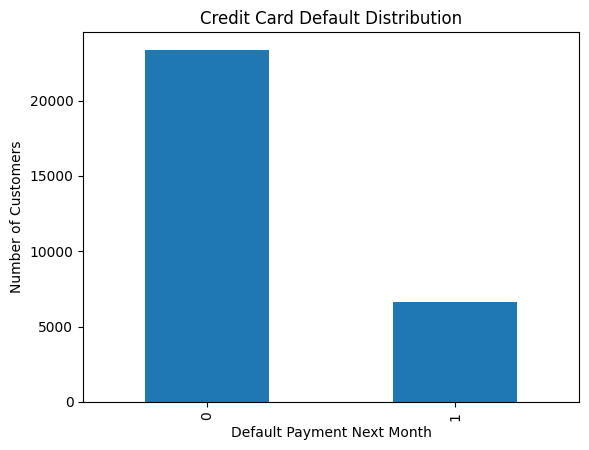

In [4]:
# ============================================================
# TARGET DISTRIBUTION
# ============================================================

target = "default payment next month"

print("Target distribution:")
print(df[target].value_counts())

df[target].value_counts().plot(kind="bar")
plt.title("Credit Card Default Distribution")
plt.xlabel("Default Payment Next Month")
plt.ylabel("Number of Customers")
plt.show()

In [5]:
# ============================================================
# FEATURE AND TARGET SEPARATION
# ============================================================

X = df.drop(columns=[target])
y = df[target]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (30000, 24)
Target shape: (30000,)


In [6]:
# ============================================================
# TRAIN / TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (24000, 24)
Testing data: (6000, 24)


In [7]:
# ============================================================
# FEATURE SCALING
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed!")
print("Scaled training shape:", X_train_scaled.shape)

Feature scaling completed!
Scaled training shape: (24000, 24)


In [8]:
# ============================================================
# BUILD ARTIFICIAL NEURAL NETWORK
# ============================================================

ann_model = MLPClassifier(
    hidden_layer_sizes=(32, 16),
    activation="relu",
    solver="adam",
    max_iter=100,
    random_state=42
)

print("ANN model created!")
print(ann_model)

ANN model created!
MLPClassifier(hidden_layer_sizes=(32, 16), max_iter=100, random_state=42)


In [9]:
# ============================================================
# TRAIN NEURAL NETWORK
# ============================================================

ann_model.fit(X_train_scaled, y_train)

print("ANN training completed!")

ANN training completed!


/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


In [10]:
# ============================================================
# PREDICTIONS
# ============================================================

y_pred = ann_model.predict(X_test_scaled)

print("Predictions generated!")
print("First 20 predictions:")
print(y_pred[:20])

Predictions generated!
First 20 predictions:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0]


In [11]:
# ============================================================
# MODEL EVALUATION
# ============================================================

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("ANN MODEL PERFORMANCE")
print("=" * 40)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

ANN MODEL PERFORMANCE
Accuracy : 0.8168
Precision: 0.6458
Recall   : 0.3806
F1 Score : 0.4789


In [12]:
# ============================================================
# CLASSIFICATION REPORT
# ============================================================

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.94      0.89      4673
           1       0.65      0.38      0.48      1327

    accuracy                           0.82      6000
   macro avg       0.74      0.66      0.68      6000
weighted avg       0.80      0.82      0.80      6000



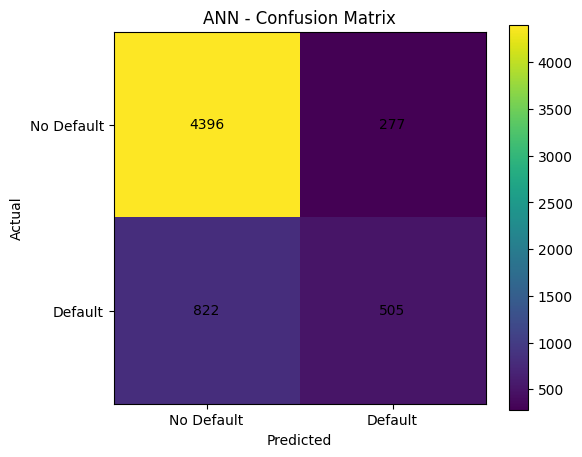

Confusion Matrix:
[[4396  277]
 [ 822  505]]


In [13]:
# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("ANN - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks([0, 1], ["No Default", "Default"])
plt.yticks([0, 1], ["No Default", "Default"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.show()

print("Confusion Matrix:")
print(cm)

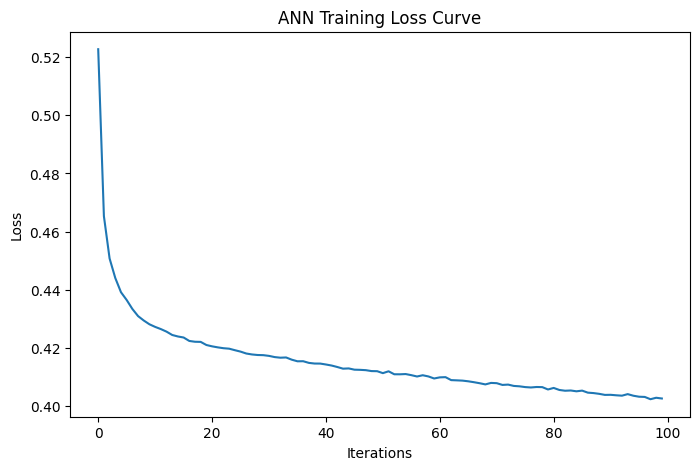

In [14]:
# ============================================================
# TRAINING LOSS CURVE
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(ann_model.loss_curve_)

plt.title("ANN Training Loss Curve")
plt.xlabel("Iterations")
plt.ylabel("Loss")

plt.show()

In [15]:
# ============================================================
# NEW CUSTOMER PREDICTION
# ============================================================

new_customer = X.iloc[[0]].copy()

new_customer_scaled = scaler.transform(new_customer)

prediction = ann_model.predict(new_customer_scaled)[0]
probability = ann_model.predict_proba(new_customer_scaled)[0]

print("NEW CUSTOMER PREDICTION")
print("=" * 40)

if prediction == 1:
    print("Prediction: Customer may default")
else:
    print("Prediction: Customer may not default")

print(f"Probability of No Default: {probability[0]:.2%}")
print(f"Probability of Default: {probability[1]:.2%}")

NEW CUSTOMER PREDICTION
Prediction: Customer may default
Probability of No Default: 28.34%
Probability of Default: 71.66%


In [16]:
# ============================================================
# SAVE ANN MODEL
# ============================================================

import joblib

joblib.dump(ann_model, "ann_credit_default_model.pkl")
joblib.dump(scaler, "ann_scaler.pkl")

print("ANN model saved successfully!")
print("Scaler saved successfully!")

ANN model saved successfully!
Scaler saved successfully!


In [17]:
# ============================================================
# FINAL CONCLUSION
# ============================================================

print("""
============================================================
FINAL CONCLUSION
============================================================

This project developed an Artificial Neural Network (ANN)
classification model to predict whether a credit card customer
is likely to default on their next payment.

The dataset was divided into training and testing sets, and
feature scaling was performed before training the neural
network. The ANN was built using two hidden layers with ReLU
activation and trained using the Adam optimizer.

The model was evaluated using Accuracy, Precision, Recall, and
F1 Score. A confusion matrix was also used to understand the
classification results, while the training loss curve showed
the model's learning behaviour during training.

The trained model was also used to generate a prediction for a
new customer.

Overall, this project demonstrates how Artificial Neural
Networks can be applied to a supervised classification problem
for credit default prediction and how model performance can be
evaluated using multiple classification metrics.

============================================================
KEY LEARNING
============================================================

1. Prepared and explored a real-world credit default dataset.
2. Applied train-test splitting and feature scaling.
3. Built and trained an Artificial Neural Network.
4. Evaluated classification performance using multiple metrics.
5. Visualized model performance using a confusion matrix and
   training loss curve.
6. Used the trained ANN to make a prediction for a new customer.

============================================================
PROJECT COMPLETE
============================================================
""")


FINAL CONCLUSION

This project developed an Artificial Neural Network (ANN)
classification model to predict whether a credit card customer
is likely to default on their next payment.

The dataset was divided into training and testing sets, and
feature scaling was performed before training the neural
network. The ANN was built using two hidden layers with ReLU
activation and trained using the Adam optimizer.

The model was evaluated using Accuracy, Precision, Recall, and
F1 Score. A confusion matrix was also used to understand the
classification results, while the training loss curve showed
the model's learning behaviour during training.

The trained model was also used to generate a prediction for a
new customer.

Overall, this project demonstrates how Artificial Neural
Networks can be applied to a supervised classification problem
for credit default prediction and how model performance can be
evaluated using multiple classification metrics.

KEY LEARNING

1. Prepared and explored a r